In [1]:
# Euskera v1.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd ..

/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera


Euskera v1.0

# Background configuration

In this notebook, we show an illustrative example of how create the background profile. For more details, see the documentation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import background as bg  # importing background package

In [5]:
bg.general()  # call the global general plot configurations

## Without self-interaction ($\lambda_n = \lambda_s = 0$)

First, we consider the case without a self-interaction term. In this situation, there is a scaling freedom, which means we can fix the central amplitude to $\sigma_0 = 1$ and derive the rest from:

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

#### Constant polarization with $n = 0, 1$ 

#### Linear polarization

Finding a profile with nodes: [0]
Final precision: U0 = [0.91857977] radius 22.334941560748167


/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


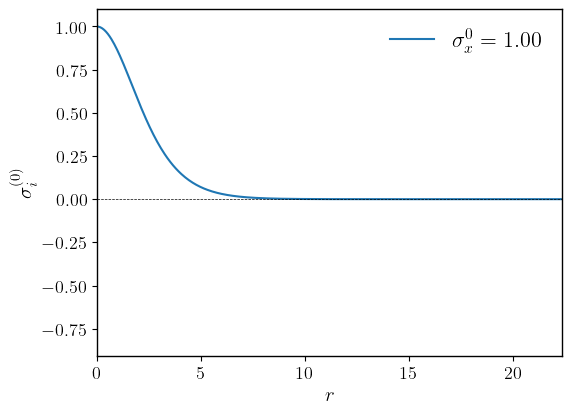

Finding a profile with nodes: [1]
Final precision: U0 = [1.209959] radius 30.286693117848095


/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


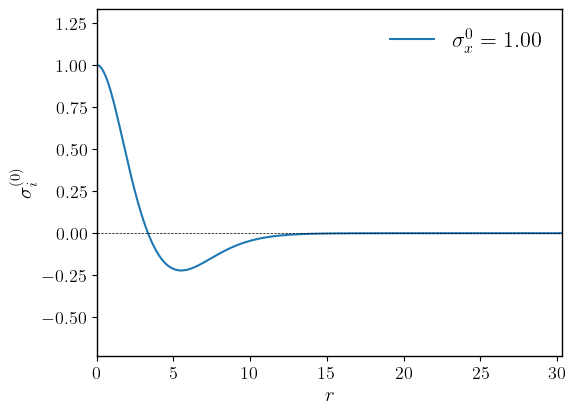

In [6]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)
nodosval = [0, 1]

p1x, u1x = 0, 0  # the first derivative value for the field (p1x) and the effective potential (u1x). Both are zero.
rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
numFields = 1

# Method
met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13 
Atol = 1e-15

# boundary conditions list
p0x = 1.0  # central amplitude of the field
Ini0 = [p0x, p1x, u1x]  

datos = []
for nodo in nodosval:  # The central amplitude of \sigma_x (p0x) and
    nodos = [nodo] 
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=[Uxint], rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg)
    
    # Save the results in a list
    datos.append([p0x, rTmax, gamma, LambT, nodos[0], numFields, met, Rtol, Atol, u0Val[0]])  # [f0, rmax, gamma, LambT, nodes, _, met, Rtol, Atol, u0]

In [7]:
# Extending the solutions
Ext = 100
Np = 200
rtake = -160

data, dataEx = [], []
for dataPerf in datos:
    en, Mas, rD, sD, dsD, uD, duD, LamV, gamma = bg.profilesFromSolut(dataPerf, info=True)  # Solving
    rDnew, sDnew, dsDnew, uDnew, duDnew = bg.extend(gamma, rD[:rtake],
                                                                sD[0][:rtake], dsD[0][:rtake],
                                                                uD[0][:rtake], duD[0][:rtake],
                                                                Ext, Np, inf=False)
    data.append([en[0], Mas[0], rD, sD[0], dsD[0], uD[0], duD[0], LamV])
    dataEx.append([en[0], Mas[0], rDnew, sDnew, dsDnew, uDnew, duDnew, LamV])

Mass values: [43.58339244901069]
Eigenvalues of energy: [-0.9789591957601331]
Mass values: [96.93636878343519]
Eigenvalues of energy: [-0.9162746282239667]


/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera/background/Background/background.py:292: UserWarning: En and Mas are not provided. We computed them from the field profile.
 IMPORTANT: for multifrequency, this procedure is not correct.
  warnings.warn("En and Mas are not provided. We computed them from the field profile.\n IMPORTANT: for multifrequency, this procedure is not correct.")


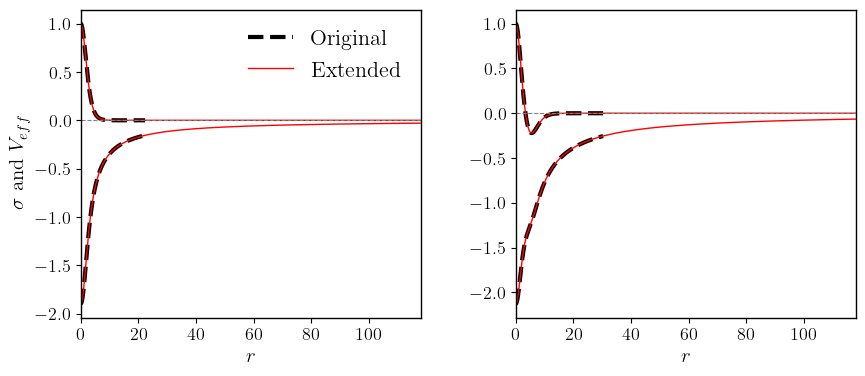

In [8]:
# show profiles
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

for i, axes in enumerate(ax):
    # original
    axes.plot(data[i][2], data[i][3], ls='--', c='k', lw=3)
    axes.plot(data[i][2], data[i][0] - data[i][5], ls='--', lw=3, c='k')

    # extension
    axes.plot(dataEx[i][2], dataEx[i][3], ls='-', c='r', lw=1)
    axes.plot(dataEx[i][2], dataEx[i][0] - dataEx[i][5], ls='-', lw=1, c='r')
    
    axes.hlines(y=0, xmin=0, xmax=118, ls='--', lw=0.8, color='gray')
    axes.set_xlim(0, 118)

ax[0].plot([],[], ls='--', c='k', lw=3, label='Original')
ax[0].plot([],[], ls='-', c='r', lw=1, label='Extended')
ax[0].set_ylabel(r'$\sigma$ and $V_{eff}$')

ax[0].set_xlabel(r'$r$')
ax[1].set_xlabel(r'$r$')
ax[0].legend(loc='upper right', frameon=False)

In [ ]:
# saving if needed
np.savez(f"profiles/profiles_const_lam_0_n_0_1.npz", np.array(dataEx, dtype=object))

####  Radial polarization

Finding a profile with nodes: [0]
Final precision: U0 = [1.69471091] radius 17.762393210062694


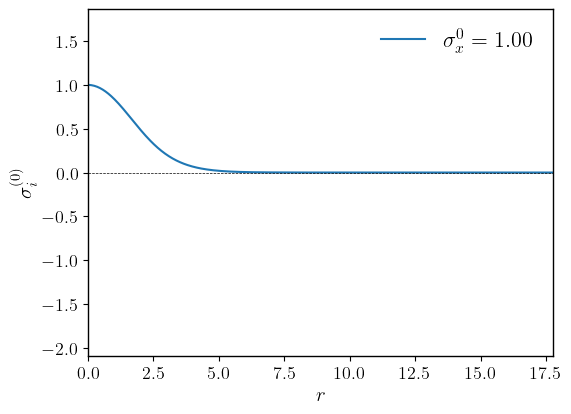

Finding a profile with nodes: [1]
Final precision: U0 = [2.06157859] radius 22.540060832468846


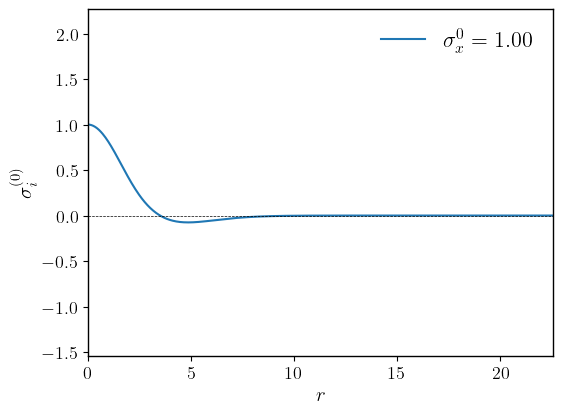

In [9]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)
nodosval = [0, 1]

p1x, u1x = 0, 0  # the first derivative value for the field (p1x) and the effective potential (u1x). Both are zero.
rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
numFields = 1

# Method
met = 'DOP853'
gamma = 1 # 0 linear
Rtol = 1e-13 
Atol = 1e-15

# boundary conditions list
p0x = 1.0  # central amplitude of the field
Ini0 = [p0x, p1x, u1x]  

datos = []
for nodo in nodosval:  # The central amplitude of \sigma_x (p0x) and
    nodos = [nodo] 
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=[Uxint], rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg)
    
    # Save the results in a list
    datos.append([p0x, rTmax, gamma, LambT, nodos[0], numFields, met, Rtol, Atol, u0Val[0]])  # [f0, rmax, gamma, LambT, nodes, _, met, Rtol, Atol, u0]

In [10]:
# Extending the solutions
Ext = 100
Np = 200
rtake = -160

data, dataEx = [], []
for dataPerf in datos:
    en, Mas, rD, sD, dsD, uD, duD, LamV, gamma = bg.profilesFromSolut(dataPerf, info=True)  # Solving
    rDnew, sDnew, dsDnew, uDnew, duDnew = bg.extend(gamma, rD[:rtake],
                                                                sD[0][:rtake], dsD[0][:rtake],
                                                                uD[0][:rtake], duD[0][:rtake],
                                                                Ext, Np, inf=False)
    
    data.append([en[0], Mas[0], rD,
                 rD**gamma * sD[0],
                 rD**(gamma-1) * (gamma * sD[0] + rD*dsD[0]),
                 uD[0], duD[0], LamV])
    dataEx.append([en[0], Mas[0], rDnew,
                   rDnew**gamma * sDnew,
                   rDnew**(gamma-1) * (gamma * sDnew + rDnew * dsDnew),
                   uDnew, duDnew, LamV])

Mass values: [119.18637009043606]
Eigenvalues of energy: [-2.4336505407338915]
Mass values: [193.33080149446695]
Eigenvalues of energy: [-2.082480506150805]


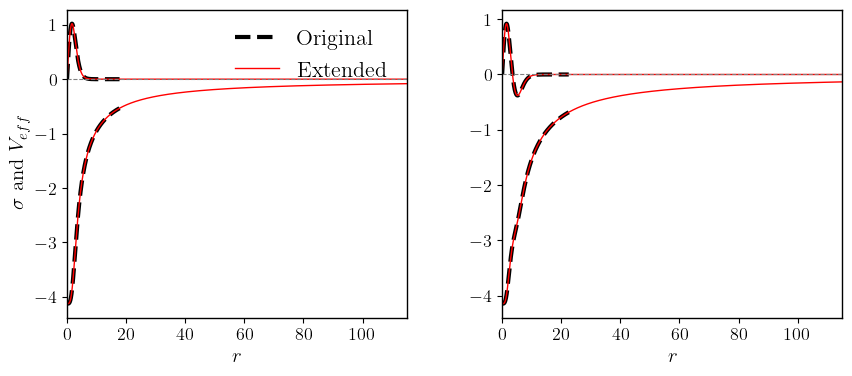

In [11]:
# show profiles
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

for i, axes in enumerate(ax):
    # original
    axes.plot(data[i][2], data[i][3], ls='--', c='k', lw=3)
    axes.plot(data[i][2], data[i][0] - data[i][5], ls='--', lw=3, c='k')

    # extension
    axes.plot(dataEx[i][2], dataEx[i][3], ls='-', c='r', lw=1)
    axes.plot(dataEx[i][2], dataEx[i][0] - dataEx[i][5], ls='-', lw=1, c='r')
    
    axes.hlines(y=0, xmin=0, xmax=118, ls='--', lw=0.8, color='gray')
    axes.set_xlim(0, 115)

ax[0].plot([],[], ls='--', c='k', lw=3, label='Original')
ax[0].plot([],[], ls='-', c='r', lw=1, label='Extended')
ax[0].set_ylabel(r'$\sigma$ and $V_{eff}$')

ax[0].set_xlabel(r'$r$')
ax[1].set_xlabel(r'$r$')
ax[0].legend(loc='upper right', frameon=False)

In [ ]:
# saving if needed
np.savez("profiles/profiles_crad_lam_0_n_0_1.npz", np.array(dataEx, dtype=object))

#### Multifrequency with a zero $z$-component

For this example we considered two Proca-multifrequency with the same mass and central amplitudes $\sigma_0 = [0.81, 0.2, 0]$ and $\sigma_0 = [0.145, 0.23, 0]$ and nodal relation $n_x=0, n_y=1$.

In [12]:
from background.Background import MultFreq_solveG2_vO

Finding a profile with nx, ny, nz [0 1 0] nodes
Found: U0x =  0.760662384033203  U0y =  1.1962460937500001  U0z =  0.0 radio 9.222347128431508


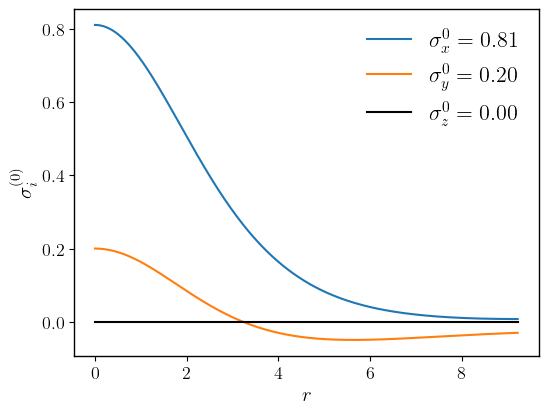

Finding a profile with nx, ny, nz [0 1 0] nodes
Found: U0x =  0.22071435546875  U0y =  0.35254296875  U0z =  0.0 radio 12.333114028343083


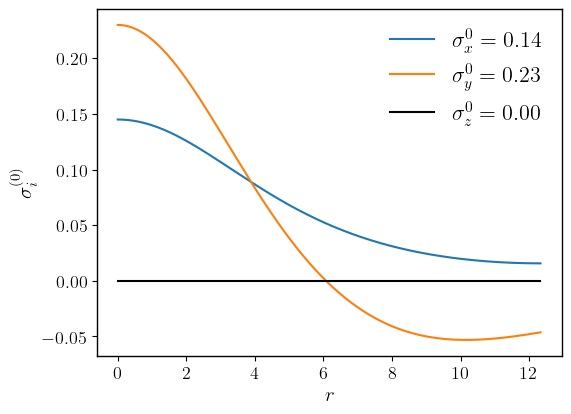

In [13]:
list_s0 = [[0.81, 0.2, 0], [0.145, 0.23, 0]]

LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx, ny, nz = 0, 1, 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx, ny, nz]  # list of node info

p1x = 0  # the first derivative value (p1x), the latter is zero
p1y = 0  # The same in y-axes
p1z = 0  # The same in z-axes
u1x, u1y, u1z = 0, 0, 0  # The first derivatives of the x, y, and z effective potential components are all zero.

# Range of values used as seed for the effective potential
Uzint = [0, 0]
Uxint = [0.001, 18]
Uyint = [0.001, 18]
    
Uintrs = [Uxint, Uyint, Uzint]
numFields = len(Uintrs)

rmax = 20  # iteration radius

met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13
Atol = 1e-15

datos = []
for s0val in list_s0:  # The central amplitude of \sigma_x (p0x) and len(s0val)
    p0x, p0y, p0z = s0val
    Ini0 = [p0x, p1x, p0y, p1y, p0z, p1z, u1x, u1y, u1z]  # boundary conditions list
    #u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
    #                                            nodos=nodos, lim=1e-20, info=False, klim=5000, outval=0, delta=0.2, Rtol=Rtol, Atol=Atol)  # part=[0,0] para componente y sola

    u0Val, rTmax, events = MultFreq_solveG2_vO(Ini0, Uintrs, rmax=rmax, LambT=LambT, rmin=0, nodos=nodos, 
                      met=met,Rtol=Rtol, Atol=Atol, lim=1e-20, info=False, klim=5000, outval=13, delta=0.2)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg, px=True, py=True, lim=False)
    
    #[U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT]
    datos.append([u0Val[0], u0Val[1], u0Val[2], rTmax, [p0x, p0y, p0z], nodos, LambT])

#### Improving the Previous Results

To improve the previous results, we use the above results as a seed and apply a second shooting method.

Stop [1.07053364e-12 1.20029448e-14 0.00000000e+00] k 500 ck [0.7608282  1.22109863 0.        ]


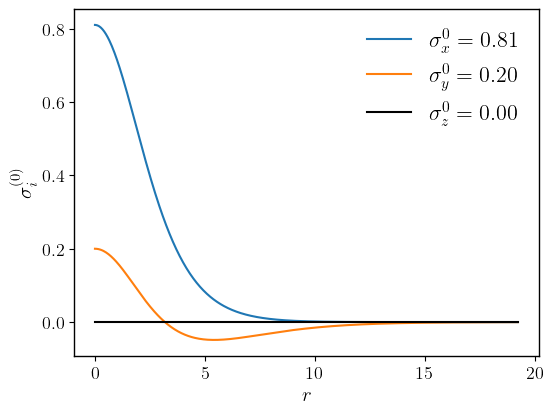

Stop [2.60920410e-15 1.27610596e-15 0.00000000e+00] k 500 ck [0.22654719 0.35258743 0.        ]


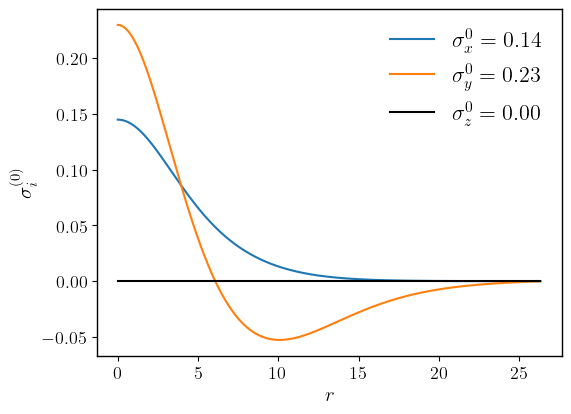

In [14]:
confidata = []
list_rext = [10, 14]
for i, datinf in enumerate(datos):
    U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT = datinf

    rext = list_rext[i] # increasing the rTmax iteration radius
    rmin, rmax = 0, rTmax + rext
    limit = [rmin, rmax]

    p1x, p1y, p1z, u1x, u1y, u1z = 0, 0, 0, 0, 0, 0  # first derivatives

    uk = [U0x, U0y, U0z]  #  seeds

    # solving
    V0X = [p0x, p1x, p0y, p1y, p0z, p1z, None, u1x, None, u1y, None, u1z]
    V0Duk = np.zeros(12*3)
    V0Duk[6] = 1
    V0Duk[20] = 1
    V0Duk[-2] = 1
    V0 = np.concatenate((V0X, V0Duk))

    # Boolenos
    indck = np.concatenate(([False, False, False, False, False, False, True, False, True, False, True, False], [False]*36))
    V0[indck] = uk

    BCind = [0, 0, 0]

    indXc = np.array([False]*48)
    indXc[:5:2] = True 

    inddXc = np.array([False]*48)
    inddXc[12::12] =  True
    inddXc[14::12] =  True
    inddXc[16::12] =  True

    arg = [LambT]

    met = 'DOP853'
    Rtol = 1e-12 # 1e-13
    Atol = 1e-14 # 1e-14

    V0fit = bg.fitting(bg.systemMultFreqTot, V0, indck, indXc, BCind, inddXc, limit, argf=arg, tol=1e-18, met=met, Rtol=Rtol, Atol=Atol)
    
    U0 = V0fit[:12]
    U0x, U0y, U0z = U0[6], U0[8], U0[10]

    confidata.append([U0x, U0y, U0z, rmax, [p0x, p0y, p0z], nodos, LambT])

    # plot
    bg.plotPerf(U0, rmax, arg=arg, met=met, Rtol=Rtol, Atol=Atol, px=True, py=True, lim=False)

Mass values: [3.4652361950866495, 3.4652361950866495, 3.4652361950866495]
Eigenvalues of energy: [-0.8473370283645028, -0.3870666028775225, -1.6081652297560398]


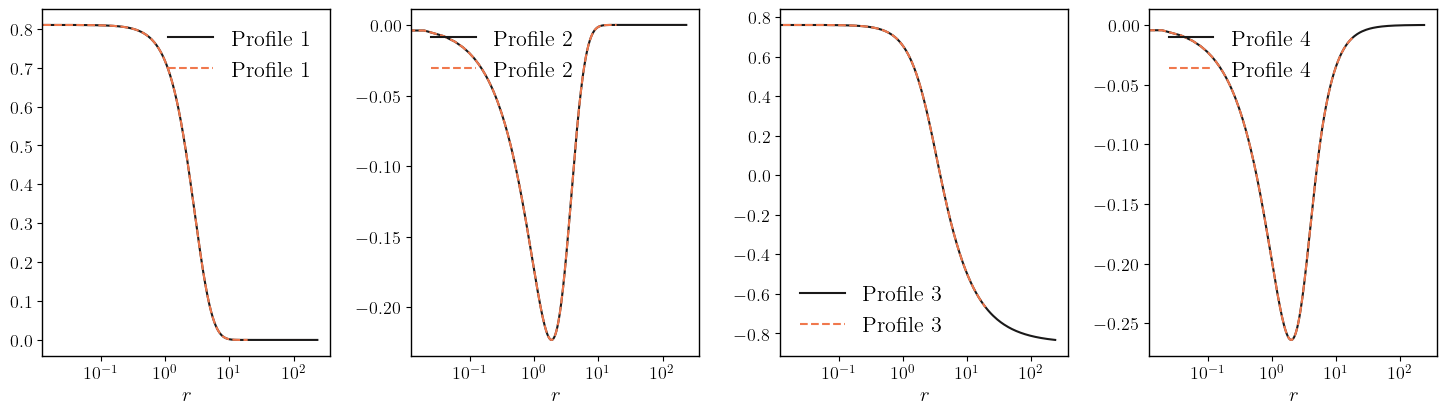

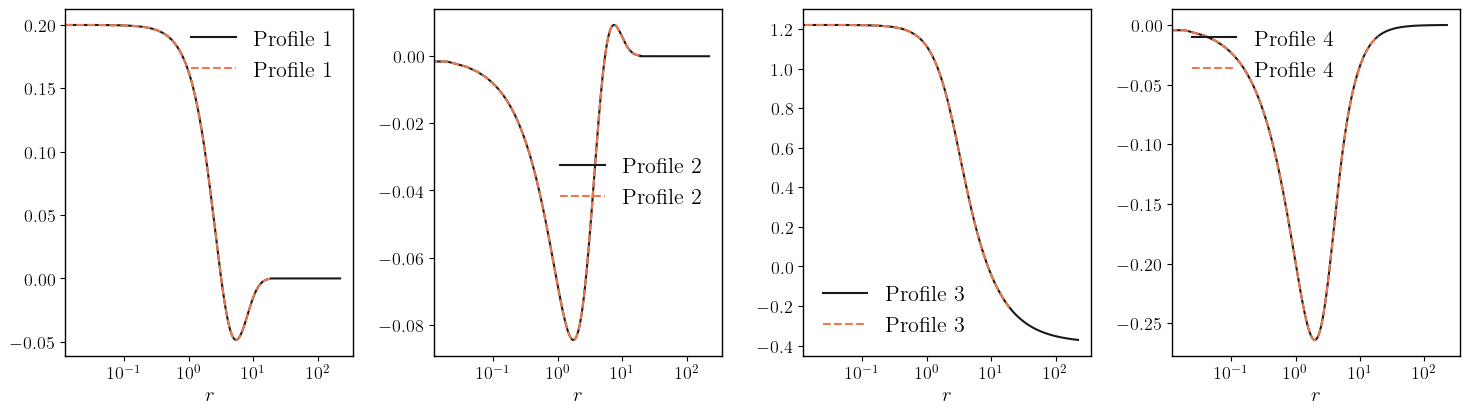

Mass values: [3.4454105041701655, 3.4454105041701655, 3.4454105041701655]
Eigenvalues of energy: [-0.34522564195687777, -0.21918539656893776, -0.5717728282674459]


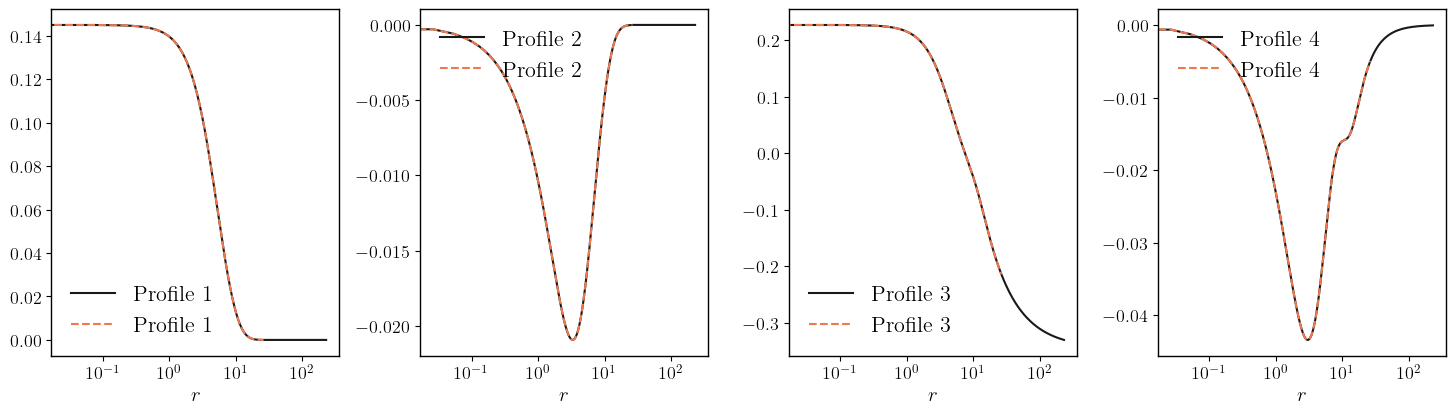

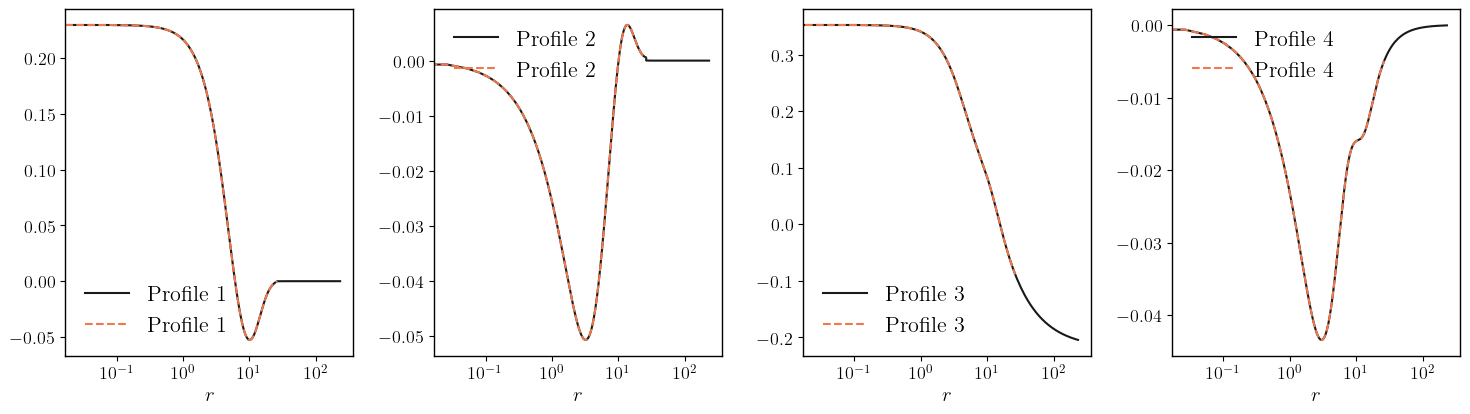

In [15]:
# Extending the solutions
Ext = 200
Np = 1000

confidataEx = []
for confi in confidata: # confidata datos
    dataEx = bg.mainExt(confi, mult=True, rmin=0, Nptos=Np, met=met, metExp=1, info=True, indF=-2,
                    Rtol=Rtol, Atol=Atol, deltaExt=Ext, yscale='linear', xscale='log')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx)

In [18]:
# Making a null data
zerof = lambda r: 0.*r

# Adding a null solution
for i in range(len(confidataEx)):
    rd = confidataEx[i][0][1]
    data0 = [0., rd, zerof(rd), zerof(rd), zerof(rd), zerof(rd)]
    # confidataEx[i].insert(0, data0). # add a null solution on the first position
    confidataEx[i].append(data0)  # add a null solution
    # confidataEx[i].append(data0)  # add a null solution


In [21]:
# saving if needed
np.savez("profiles/profiles_proc_lam_0_2config.npz", np.array(confidataEx, dtype=object))

## With self-interaction term

Next, we identify a soliton solution where $\lambda = 1$ (repulsive case). Notice that, alternatively, we can consider a self-interacting Proca configuration with zero $y$ and $z$ components.

Finding a profile with nodes: [0]
Final precision: U0 = [1.47964441] radius 19.98176292409417


/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera/background/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


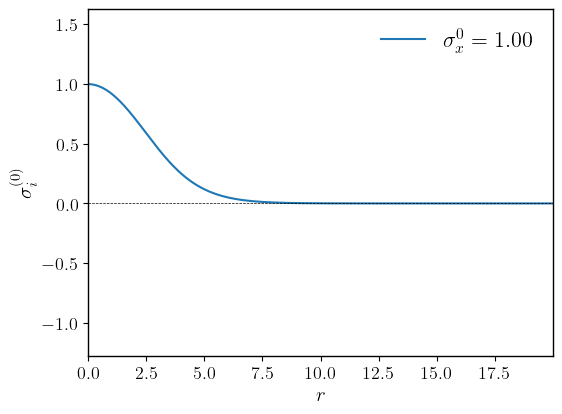

Finding a profile with nodes: [1]
Final precision: U0 = [1.66761588] radius 26.794201763097895


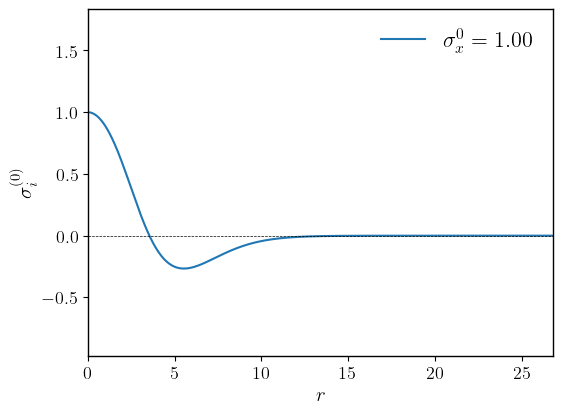

In [22]:
LambT = 1 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)
nodosval = [0, 1]

p1x, u1x = 0, 0  # the first derivative value for the field (p1x) and the effective potential (u1x). Both are zero.
rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
numFields = 1

# Method
met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13 
Atol = 1e-15

# boundary conditions list
p0x = 1.0  # central amplitude of the field
Ini0 = [p0x, p1x, u1x]  

datos = []
for nodo in nodosval:  # The central amplitude of \sigma_x (p0x) and
    nodos = [nodo] 
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=[Uxint], rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    bg.plotPerf(U0, rTmax, arg=arg)
    
    # Save the results in a list
    datos.append([p0x, rTmax, gamma, LambT, nodos[0], numFields, met, Rtol, Atol, u0Val[0]])  # [f0, rmax, gamma, LambT, nodes, _, met, Rtol, Atol, u0]

For the next step, the above example can be used.